In [1]:
%pip install pandas matplotlib seaborn textblob nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# ================================================
# Notebook 03 — Feature Engineering & Engagement Scoring
# Project: Ad Engagement Analysis
# Goal: Build a custom business metric to rank ad effectiveness
# ================================================

In this notebook, we move beyond just counting interactions. We are going to build a custom **Engagement Effectiveness Score**.

### The Business Logic:
Not all interactions are equal.
- Base Comment = **1 point** (Minimum effort)
- Emoji Used = **+2 points** (Shows active emotional reaction)
- Hashtags Used = **+1 point per hashtag** (Shows intent to amplify/share the ad visually)

Combining these gives us a weighted score, allowing us to find the campaigns that truly performed the best!

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# Load and clean the dataset
df = pd.read_csv('../data/comments_cleaned.csv')

if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
    
df.rename(columns={
    'User  id': 'user_id',
    'Photo id': 'campaign_id',
    'created Timestamp': 'timestamp',
    'posted date': 'posted_date',
    'emoji used': 'emoji_used',
    'Hashtags used count': 'hashtag_count'
}, inplace=True)

print("Data loaded successfully.")

Data loaded successfully.


In [3]:
# 1. Feature Engineering: The Engagement Score
# Create the individual components
df['base_comment_score'] = 1
df['emoji_score'] = df['emoji_used'].apply(lambda x: 2 if x == 'yes' else 0)
# hashtag_count is already an integer from 0 to 6

# Calculate Total Score
df['engagement_score'] = df['base_comment_score'] + df['emoji_score'] + df['hashtag_count']

# Let's see some extremely high vs low engagement comments
print("Sample of scored interactions:")
df[['campaign_id', 'comment', 'emoji_used', 'hashtag_count', 'engagement_score']].sample(5, random_state=42)

Sample of scored interactions:


,campaign_id,comment,emoji_used,hashtag_count,engagement_score
2827,98,est quae unde,no,5,6
2858,99,voluptas eaque vero,no,4,5
2133,74,voluptas molestias pariatur,yes,2,5
5310,182,deserunt ullam autem,yes,0,3
3626,126,cupiditate eveniet voluptate,no,4,5


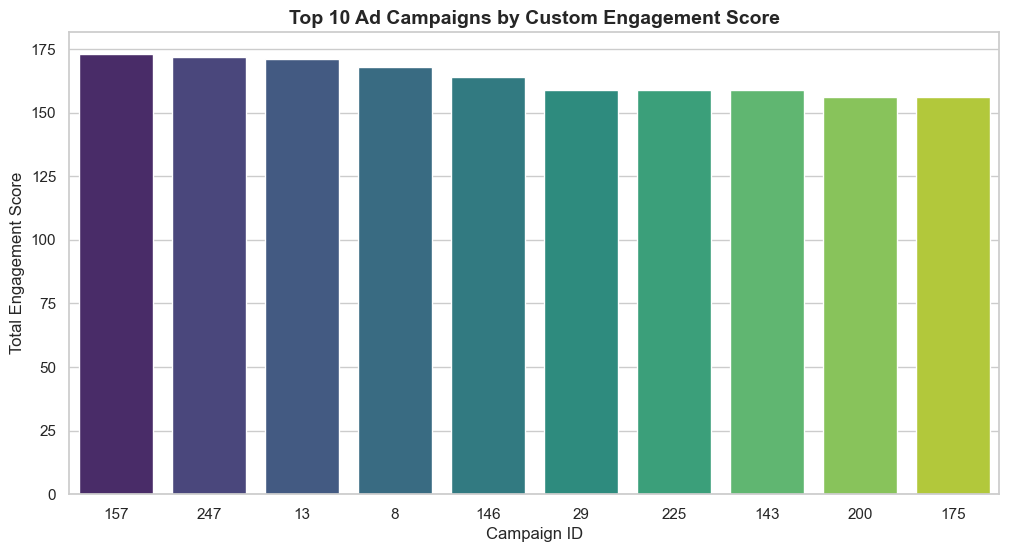

In [4]:
# 2. Campaign Level Performance
# Let's aggregate these individual scores to the campaign level!

campaign_performance = df.groupby('campaign_id').agg(
    total_interactions=('user_id', 'count'),
    total_engagement_score=('engagement_score', 'sum'),
    avg_engagement_score=('engagement_score', 'mean')
).reset_index()

# Sort to find the highest-performing campaigns based on true engagement
top_campaigns = campaign_performance.sort_values(by='total_engagement_score', ascending=False).head(10)

plt.figure(figsize=(12, 6))
# Create a bar plot using the new custom metric
sns.barplot(
    data=top_campaigns, 
    x=top_campaigns['campaign_id'].astype(str), 
    y='total_engagement_score', 
    palette='viridis'
)
plt.title('Top 10 Ad Campaigns by Custom Engagement Score', fontsize=14, fontweight='bold')
plt.xlabel('Campaign ID')
plt.ylabel('Total Engagement Score')
plt.show()

In [5]:
# 3. Save Final Analytical Data to CSV
# We will need these enriched data files to power the Streamlit Dashboard (Day 5)

# Save the user-interaction level data with scores
df.to_csv('../data/ad_interactions_scored.csv', index=False)

# Save the campaign-level aggregated performance metrics
campaign_performance.to_csv('../data/campaign_performance.csv', index=False)

print(" Feature Engineered datasets successfully saved to /data folder!")

 Feature Engineered datasets successfully saved to /data folder!


In [6]:
# 4. Quick Validation Checks
required_columns = ['campaign_id', 'comment', 'emoji_used', 'hashtag_count', 'engagement_score']

# Check for missing required columns
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    print(f"Missing required columns: {missing_columns}")
else:
    print("All required columns are present.")

# Validate emoji values used by scoring logic
allowed_emoji_values = {'yes', 'no'}
emoji_series = df['emoji_used']
emoji_normalized = emoji_series.dropna().astype(str).str.strip().str.lower()
invalid_emoji_values = sorted(set(emoji_normalized.unique()) - allowed_emoji_values)
null_emoji_count = int(emoji_series.isna().sum())

if invalid_emoji_values:
    print(f"Unexpected emoji_used values found: {invalid_emoji_values}")
else:
    print("emoji_used values are valid (yes/no only).")

if null_emoji_count > 0:
    print(f"Warning: emoji_used has {null_emoji_count} missing values.")

# Engagement score min/max sanity check
score_min = df['engagement_score'].min()
score_max = df['engagement_score'].max()
print(f"Engagement score range: min={score_min}, max={score_max}")

# Validate exported row counts against in-memory DataFrames
ad_interactions_export = pd.read_csv('../data/ad_interactions_scored.csv')
campaign_performance_export = pd.read_csv('../data/campaign_performance.csv')

print(
    f"ad_interactions_scored.csv rows: {len(ad_interactions_export)} (expected {len(df)})"
)
print(
    f"campaign_performance.csv rows: {len(campaign_performance_export)} (expected {len(campaign_performance)})"
)

if len(ad_interactions_export) == len(df) and len(campaign_performance_export) == len(campaign_performance):
    print("Export row-count validation passed.")
else:
    print("Export row-count validation failed.")

All required columns are present.
emoji_used values are valid (yes/no only).
Engagement score range: min=3, max=7
ad_interactions_scored.csv rows: 7488 (expected 7488)
campaign_performance.csv rows: 257 (expected 257)
Export row-count validation passed.


## 5. Decision Insights: Top/Bottom Campaigns
Now that data quality checks pass, we can summarize performance in a decision-ready format.

This section identifies:
- Top campaigns by total engagement score
- Bottom campaigns by total engagement score
- Score spread (variability) across campaigns

Top 5 Campaigns by Total Engagement Score


,campaign_id,total_interactions,total_engagement_score,avg_engagement_score
0,157,39,173,4.435897
1,247,39,172,4.410256
2,13,39,171,4.384615
3,8,38,168,4.421053
4,146,37,164,4.432432


Bottom 5 Campaigns by Total Engagement Score


,campaign_id,total_interactions,total_engagement_score,avg_engagement_score
256,179,21,93,4.428571
255,230,22,98,4.454545
254,16,22,98,4.454545
253,129,23,99,4.304348
252,17,23,102,4.434783


Engagement score spread across campaigns: 80


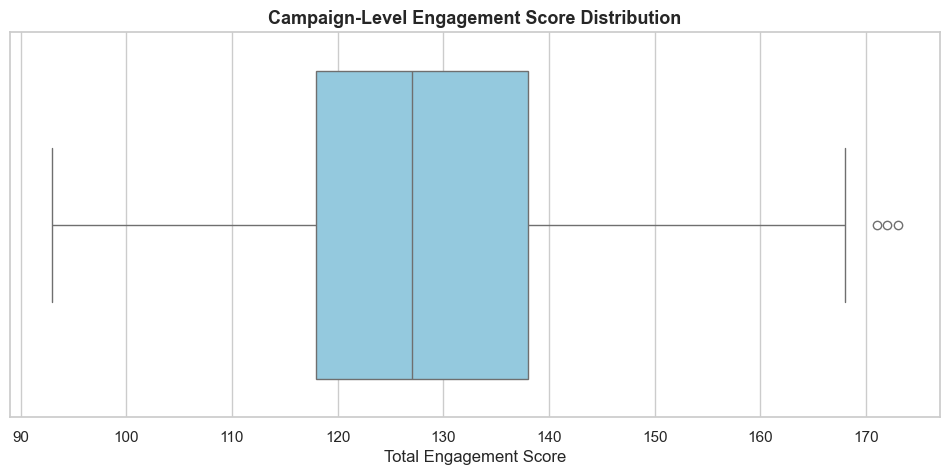

In [7]:
# 5A. Campaign ranking insights
ranked_campaigns = campaign_performance.sort_values('total_engagement_score', ascending=False).reset_index(drop=True)

top_5 = ranked_campaigns.head(5).copy()
bottom_5 = ranked_campaigns.tail(5).sort_values('total_engagement_score', ascending=True).copy()

print('Top 5 Campaigns by Total Engagement Score')
display(top_5)

print('Bottom 5 Campaigns by Total Engagement Score')
display(bottom_5)

score_spread = ranked_campaigns['total_engagement_score'].max() - ranked_campaigns['total_engagement_score'].min()
print(f'Engagement score spread across campaigns: {score_spread}')

plt.figure(figsize=(12, 5))
sns.boxplot(data=ranked_campaigns, x='total_engagement_score', color='skyblue')
plt.title('Campaign-Level Engagement Score Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Total Engagement Score')
plt.show()

### Business Interpretation
- If top campaigns are only slightly better than average, scaling strategy should focus on improving creative quality first.
- If there is a large spread, replicate design patterns from top campaigns and retire low performers.
- Combine this ranking with sentiment outputs from Notebook 02 to identify campaigns that are both high-engagement and positively perceived.

## 6. Sentiment + Engagement Merge Analysis
This section computes sentiment from comments and connects it with engagement score to answer:
- Are positive comments associated with stronger engagement?
- Which campaigns are high-engagement and positively perceived?

In [8]:
from textblob import TextBlob

# 6A. Interaction-level sentiment scoring
df['sentiment_polarity'] = df['comment'].astype(str).apply(lambda text: TextBlob(text).sentiment.polarity)

def polarity_label(p):
    if p > 0.05:
        return 'positive'
    if p < -0.05:
        return 'negative'
    return 'neutral'

df['sentiment_label'] = df['sentiment_polarity'].apply(polarity_label)

print('Sentiment label distribution:')
display(df['sentiment_label'].value_counts().to_frame('count'))

interaction_corr = df['sentiment_polarity'].corr(df['engagement_score'])
print(f"Correlation (interaction-level): sentiment polarity vs engagement score = {interaction_corr:.4f}")

Sentiment label distribution:


,count
sentiment_label,
neutral,7411
negative,77


Correlation (interaction-level): sentiment polarity vs engagement score = 0.0001


Correlation (campaign-level): avg sentiment polarity vs total engagement score = -0.1602


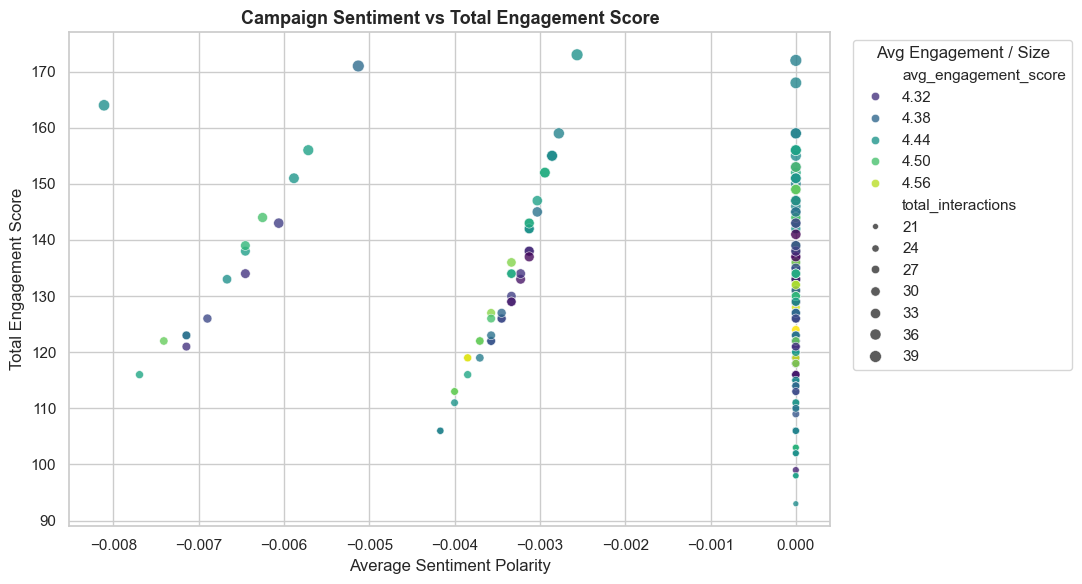

Top 10 campaigns by engagement with sentiment context:


,campaign_id,total_interactions,total_engagement_score,avg_engagement_score,avg_sentiment_polarity,positive_share
156,157,39,173,4.435897,-0.002564,0.0
246,247,39,172,4.410256,0.000000,0.0
12,13,39,171,4.384615,-0.005128,0.0
7,8,38,168,4.421053,0.000000,0.0
145,146,37,164,4.432432,-0.008108,0.0
28,29,36,159,4.416667,0.000000,0.0
224,225,36,159,4.416667,0.000000,0.0
142,143,36,159,4.416667,-0.002778,0.0
94,95,35,156,4.457143,0.000000,0.0
199,200,35,156,4.457143,0.000000,0.0


In [9]:
# 6B. Campaign-level merge: sentiment + engagement
campaign_sentiment = (
    df.groupby('campaign_id', as_index=False)
      .agg(
          avg_sentiment_polarity=('sentiment_polarity', 'mean'),
          positive_share=('sentiment_label', lambda s: (s == 'positive').mean())
      )
)

campaign_sentiment_engagement = campaign_performance.merge(
    campaign_sentiment, on='campaign_id', how='left'
)

campaign_corr = campaign_sentiment_engagement['avg_sentiment_polarity'].corr(
    campaign_sentiment_engagement['total_engagement_score']
)
print(f"Correlation (campaign-level): avg sentiment polarity vs total engagement score = {campaign_corr:.4f}")

plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=campaign_sentiment_engagement,
    x='avg_sentiment_polarity',
    y='total_engagement_score',
    size='total_interactions',
    hue='avg_engagement_score',
    palette='viridis',
    alpha=0.8
    )
plt.title('Campaign Sentiment vs Total Engagement Score', fontsize=13, fontweight='bold')
plt.xlabel('Average Sentiment Polarity')
plt.ylabel('Total Engagement Score')
plt.legend(title='Avg Engagement / Size', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Highlight campaigns that are both high-engagement and positive in sentiment
top_sentiment_engagement = campaign_sentiment_engagement.sort_values(
    by=['total_engagement_score', 'avg_sentiment_polarity'], ascending=False
).head(10)

print('Top 10 campaigns by engagement with sentiment context:')
display(top_sentiment_engagement[['campaign_id', 'total_interactions', 'total_engagement_score', 'avg_engagement_score', 'avg_sentiment_polarity', 'positive_share']])

## 7. Enhanced Sentiment (VADER) and Final Recommendations
To reduce neutral-heavy sentiment results, this step applies VADER sentiment and compares it to TextBlob.

Then we combine VADER sentiment with engagement to identify priority campaigns for scaling or optimization.

In [10]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# 7A. VADER sentiment scoring with safe lexicon setup
try:
    sia = SentimentIntensityAnalyzer()
except LookupError:
    nltk.download('vader_lexicon')
    sia = SentimentIntensityAnalyzer()

df['vader_compound'] = df['comment'].astype(str).apply(lambda text: sia.polarity_scores(text)['compound'])

def vader_label(c):
    if c >= 0.05:
        return 'positive'
    if c <= -0.05:
        return 'negative'
    return 'neutral'

df['vader_label'] = df['vader_compound'].apply(vader_label)

print('VADER label distribution:')
display(df['vader_label'].value_counts().to_frame('count'))

vader_interaction_corr = df['vader_compound'].corr(df['engagement_score'])
print(f"Correlation (interaction-level): VADER compound vs engagement score = {vader_interaction_corr:.4f}")

comparison = pd.DataFrame({
    'textblob': df['sentiment_label'].value_counts(),
    'vader': df['vader_label'].value_counts()
}).fillna(0).astype(int)
print('TextBlob vs VADER label counts:')
display(comparison)

VADER label distribution:


,count
vader_label,
neutral,7408
negative,80


Correlation (interaction-level): VADER compound vs engagement score = 0.0039
TextBlob vs VADER label counts:


,textblob,vader
neutral,7411,7408
negative,77,80


In [11]:
# 7B. Final campaign decision table using VADER + engagement
campaign_vader = (
    df.groupby('campaign_id', as_index=False)
      .agg(
          avg_vader_compound=('vader_compound', 'mean'),
          vader_positive_share=('vader_label', lambda s: (s == 'positive').mean())
      )
)

campaign_final = campaign_performance.merge(campaign_vader, on='campaign_id', how='left')
campaign_final['engagement_rank'] = campaign_final['total_engagement_score'].rank(ascending=False, method='dense')
campaign_final['sentiment_rank'] = campaign_final['avg_vader_compound'].rank(ascending=False, method='dense')
campaign_final['priority_index'] = campaign_final['engagement_rank'] + campaign_final['sentiment_rank']

final_top10 = campaign_final.sort_values('priority_index', ascending=True).head(10).copy()
final_bottom10 = campaign_final.sort_values('priority_index', ascending=False).head(10).copy()

print('Top 10 priority campaigns (high engagement + better sentiment):')
display(final_top10[['campaign_id', 'total_interactions', 'total_engagement_score', 'avg_engagement_score', 'avg_vader_compound', 'vader_positive_share', 'priority_index']])

print('Bottom 10 campaigns to optimize (lower priority index performance):')
display(final_bottom10[['campaign_id', 'total_interactions', 'total_engagement_score', 'avg_engagement_score', 'avg_vader_compound', 'vader_positive_share', 'priority_index']])

campaign_final.to_csv('../data/campaign_sentiment_engagement_final.csv', index=False)
print('Saved: ../data/campaign_sentiment_engagement_final.csv')

Top 10 priority campaigns (high engagement + better sentiment):


,campaign_id,total_interactions,total_engagement_score,avg_engagement_score,avg_vader_compound,vader_positive_share,priority_index
12,13,39,171,4.384615,0.000000,0.0,4.0
246,247,39,172,4.410256,-0.010305,0.0,4.0
145,146,37,164,4.432432,0.000000,0.0,6.0
28,29,36,159,4.416667,0.000000,0.0,7.0
7,8,38,168,4.421053,-0.010576,0.0,7.0
224,225,36,159,4.416667,0.000000,0.0,7.0
226,227,35,156,4.457143,0.000000,0.0,8.0
174,175,35,156,4.457143,0.000000,0.0,8.0
117,118,35,155,4.428571,0.000000,0.0,9.0
238,239,35,155,4.428571,0.000000,0.0,9.0


Bottom 10 campaigns to optimize (lower priority index performance):


,campaign_id,total_interactions,total_engagement_score,avg_engagement_score,avg_vader_compound,vader_positive_share,priority_index
183,184,24,106,4.416667,-0.033492,0.0,74.0
229,230,22,98,4.454545,-0.018268,0.0,70.0
230,231,26,114,4.384615,-0.030915,0.0,68.0
68,69,24,106,4.416667,-0.016746,0.0,65.0
250,251,24,106,4.416667,-0.016746,0.0,65.0
210,211,24,106,4.416667,-0.016746,0.0,65.0
54,55,27,118,4.370370,-0.029770,0.0,64.0
247,248,25,110,4.400000,-0.016076,0.0,62.0
219,220,25,111,4.440000,-0.016076,0.0,61.0
5,6,29,126,4.344828,-0.041576,0.0,60.0


Saved: ../data/campaign_sentiment_engagement_final.csv
